# Denoising Autoencoders
## Learning Robust Representations on Fashion-MNIST

**About**

NAME : EBENEZER OKUNOLA

STUDENT ID: 24119439


**GitHub:** https://github.com/Princebenj/denoising-autoencoder-tutorial.git

**References:**
Chollet, F. et al. (2015) Keras. Available at: https://keras.io (Accessed: 27 March 2026)
Goodfellow, I., Bengio, Y. and Courville, A. (2016) Deep Learning. Cambridge, MA: MIT Press. Available at: https://www.deeplearningbook.org (Accessed: 27 March 2026)

Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine learning in Python’, Journal of Machine Learning Research, 12, pp. 2825–2830. Available at: https://scikit-learn.org (Accessed: 27 March 2026)

Vincent, P., Larochelle, H., Bengio, Y. and Manzagol, P.-A. (2008) ‘Extracting and composing robust features with denoising autoencoders’, Proceedings of the 25th International Conference on Machine Learning (ICML), pp. 1096–1103. Available at: https://dl.acm.org/doi/10.1145/1390156.1390294 (Accessed: 27 March 2026)

Wong, B. (2011) ‘Color blindness’, Nature Methods, 8(6), p. 441. Available at: https://doi.org/10.1038/nmeth.1618 (Accessed: 27 March 2026)

Xiao, H., Rasul, K. and Vollgraf, R. (2017) ‘Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms’, arXiv:1708.07747. Available at: https://arxiv.org/abs/1708.07747 (Accessed: 27 March 2026)

## Cell 1 - Install packages
Uncomment the line below if running in a fresh environment.


In [2]:
import sys
!{sys.executable} -m pip install tensorflow numpy pandas matplotlib scikit-learn


## Cell 2 - Import libraries and set random seeds

**What this cell does:**
- Imports all required libraries.
- Fixes random seeds in NumPy, TensorFlow, and Python's `random` module for reproducibility.
- Creates the `figures/` output directory.
- Defines the Wong (2011) colourblind-safe palette used in every figure.

**Why this matters:** Reproducibility is a core requirement of good scientific practice. Fixing seeds ensures the same train/validation split and similar weight initialisations every run.


In [3]:
import os, random, itertools
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Wong (2011) colourblind-safe palette used in ALL coloured figures
CB_PALETTE = [
    '#E69F00', '#56B4E9', '#009E73', '#F0E442',
    '#0072B2', '#D55E00', '#CC79A7', '#000000',
    '#999999', '#882255'
]

print('TensorFlow version:', tf.__version__)
print('NumPy version:     ', np.__version__)


TensorFlow version: 2.19.0
NumPy version:      2.0.2


## Cell 3 - Load, normalise, and split Fashion-MNIST

**What this cell does:**
- Loads Fashion-MNIST directly from Keras (auto-downloads ~30 MB on first run).
- Converts pixel values from uint8 [0-255] to float32 [0-1].
- Creates a stratified validation split (10%) so class proportions are preserved.

**Why normalise to [0,1]?** The decoder output uses sigmoid, so pixel values lie in [0,1]. This matches binary cross-entropy as the reconstruction loss treating each pixel as a Bernoulli random variable (Vincent et al., 2008).


In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Stratified 10% validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

print('Train:', x_train.shape, y_train.shape)
print('Val:  ', x_val.shape,   y_val.shape)
print('Test: ', x_test.shape,  y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (54000, 28, 28) (54000,)
Val:   (6000, 28, 28) (6000,)
Test:  (10000, 28, 28) (10000,)


## Cell 4 - Display sample images

**What this cell does:** Plots the first ten training images in a 2x5 grid with class labels.

**Accessibility:** Greyscale images are safe for all forms of colour-vision deficiency.
Alt-text: A 2-by-5 grid of greyscale 28-by-28 fashion images showing one example from each of the ten clothing and footwear categories.


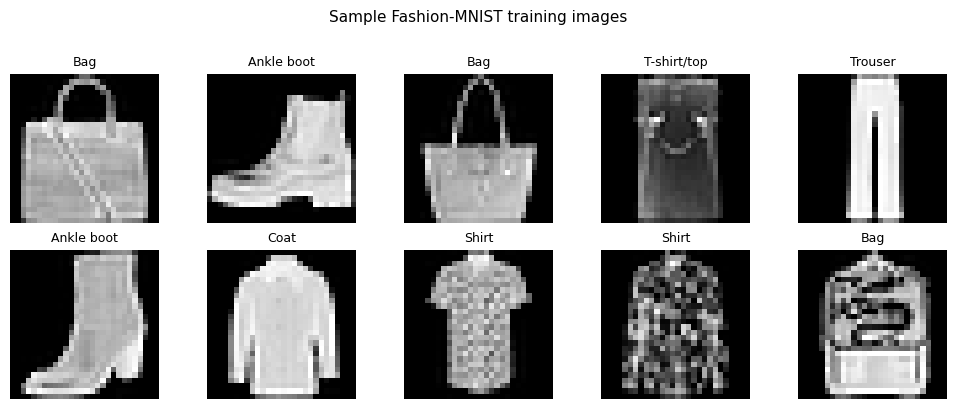

Figure 1 saved.


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9)
    ax.axis('off')
fig.suptitle('Sample Fashion-MNIST training images', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_sample_images.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


## Cell 5 - Utility functions

**What this cell does:**
- `add_gaussian_noise` adds zero-mean Gaussian noise clipped to [0, 1].
- `flatten_images` reshapes (N, 28, 28) to (N, 784) vectors.
- `build_autoencoder` constructs a symmetric fully-connected autoencoder with a configurable bottleneck, returning both the full autoencoder and encoder sub-model.

**Architecture:** 784 -> 256 -> 128 -> bottleneck -> 128 -> 256 -> 784. ReLU activations throughout; sigmoid on the output so values lie in [0, 1].

**Why binary cross-entropy?** With sigmoid outputs and normalised pixels in [0,1], treating each pixel as a Bernoulli variable makes BCE the natural reconstruction loss (Vincent et al., 2008, Section 4).


In [6]:
def add_gaussian_noise(images: np.ndarray, noise_std: float = 0.3) -> np.ndarray:
    """Return images corrupted by zero-mean Gaussian noise, clipped to [0, 1]."""
    noisy = images + np.random.normal(loc=0.0, scale=noise_std, size=images.shape)
    return np.clip(noisy, 0.0, 1.0)


def flatten_images(images: np.ndarray) -> np.ndarray:
    """Reshape (N, H, W) array to (N, H*W)."""
    return images.reshape(len(images), -1)


def build_autoencoder(input_dim: int = 784, bottleneck_dim: int = 32):
    """
    Build a symmetric fully-connected autoencoder.

    Parameters
    ----------
    input_dim     : dimensionality of flattened input (784 for 28x28 images)
    bottleneck_dim: size of the compressed latent representation

    Returns
    -------
    autoencoder : compiled Keras Model (input -> reconstruction)
    encoder     : Keras Model (input -> bottleneck)
    """
    inputs     = keras.Input(shape=(input_dim,), name='input')
    x          = layers.Dense(256, activation='relu', name='enc_256')(inputs)
    x          = layers.Dense(128, activation='relu', name='enc_128')(x)
    bottleneck = layers.Dense(bottleneck_dim, activation='relu',
                              name='bottleneck')(x)
    x          = layers.Dense(128, activation='relu', name='dec_128')(bottleneck)
    x          = layers.Dense(256, activation='relu', name='dec_256')(x)
    outputs    = layers.Dense(input_dim, activation='sigmoid',
                              name='reconstruction')(x)

    autoencoder = keras.Model(inputs, outputs,
                              name=f'autoencoder_b{bottleneck_dim}')
    encoder     = keras.Model(inputs, bottleneck,
                              name=f'encoder_b{bottleneck_dim}')
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return autoencoder, encoder


# Pre-flatten all splits once
x_train_flat = flatten_images(x_train)
x_val_flat   = flatten_images(x_val)
x_test_flat  = flatten_images(x_test)

print('Flattened shapes:')
print('  train:', x_train_flat.shape)
print('  val:  ', x_val_flat.shape)
print('  test: ', x_test_flat.shape)


Flattened shapes:
  train: (54000, 784)
  val:   (6000, 784)
  test:  (10000, 784)


## Cell 6 - Visualise corruption levels

**What this cell does:** Shows the same five images at noise levels sigma = 0.1, 0.3, and 0.5 so the reader can calibrate intuition before seeing results.

Alt-text: Three rows of five greyscale fashion images showing increasing pixel noise from top (barely visible, sigma=0.1) to bottom (near-unrecognisable, sigma=0.5).


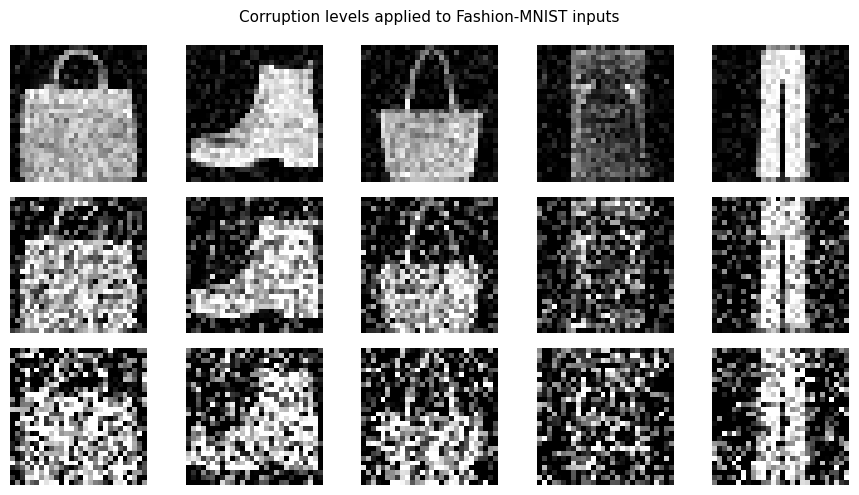

Figure 2 saved.


In [7]:
NOISE_LEVELS = [0.1, 0.3, 0.5]
N_EXAMPLES   = 5

fig, axes = plt.subplots(len(NOISE_LEVELS), N_EXAMPLES, figsize=(9, 5))
for r, noise in enumerate(NOISE_LEVELS):
    noisy_batch = add_gaussian_noise(x_train[:N_EXAMPLES], noise)
    for c in range(N_EXAMPLES):
        axes[r, c].imshow(noisy_batch[c], cmap='gray', vmin=0, vmax=1)
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(f'sigma={noise}', fontsize=10,
                          rotation=0, labelpad=60, va='center')

fig.suptitle('Corruption levels applied to Fashion-MNIST inputs', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_corruption_examples.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


## Cell 7 - Train plain autoencoder baseline

**What this cell does:** Trains a standard autoencoder (clean input -> clean target) with bottleneck size 32. Uses early stopping (patience=3) to prevent overfitting.

**Why a baseline?** Without a plain AE to compare against it is impossible to judge whether the denoising objective provides any benefit.


In [8]:
BASELINE_BOTTLENECK = 32

baseline_ae, baseline_encoder = build_autoencoder(
    bottleneck_dim=BASELINE_BOTTLENECK
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history_baseline = baseline_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_val_flat, x_val_flat),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

print('Baseline training complete.')


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - loss: 0.3407 - val_loss: 0.3046
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.2986 - val_loss: 0.2943
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2912 - val_loss: 0.2891
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.2871 - val_loss: 0.2856
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.2843 - val_loss: 0.2832
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.2820 - val_loss: 0.2814
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.2804 - val_loss: 0.2800
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.2791 - val_loss: 0.2789
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.2780 - val_loss: 0.2778
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.2769 - val_loss: 0.2770
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.2761 - val_loss: 0.2763
Epoch 12/20
422/422 ━━━━━━━━━━━━━━━━━━━━

## Cell 8 - Train denoising autoencoders across all settings

**What this cell does:**
- Defines a grid: bottleneck in {16, 32, 64} x noise sigma in {0.1, 0.3, 0.5} = 9 models.
- For each combination: corrupts inputs, trains a DAE (noisy input -> clean target), records the best validation loss.
- Stores all trained models, encoders, and histories for later analysis.

**Why this matters:** Systematically sweeping hyper-parameters turns a single demonstration into a controlled experiment showing how compression strength and corruption severity interact.


In [9]:
BOTTLENECKS        = [16, 32, 64]
NOISE_LEVELS_TRAIN = [0.1, 0.3, 0.5]

results   = []
histories = {}
models    = {}
encoders  = {}

for bottleneck_dim, noise_std in itertools.product(BOTTLENECKS, NOISE_LEVELS_TRAIN):
    print(f'\nTraining  bottleneck={bottleneck_dim:>2d}  noise_std={noise_std}')

    model, encoder = build_autoencoder(bottleneck_dim=bottleneck_dim)

    x_train_noisy = flatten_images(add_gaussian_noise(x_train, noise_std))
    x_val_noisy   = flatten_images(add_gaussian_noise(x_val,   noise_std))

    history = model.fit(
        x_train_noisy, x_train_flat,
        validation_data=(x_val_noisy, x_val_flat),
        epochs=20,
        batch_size=128,
        callbacks=[early_stop],
        verbose=1
    )

    best_val_loss = min(history.history['val_loss'])

    results.append({
        'bottleneck':    bottleneck_dim,
        'noise':         noise_std,
        'best_val_loss': best_val_loss
    })
    histories[(bottleneck_dim, noise_std)] = history.history
    models[(bottleneck_dim, noise_std)]    = model
    encoders[(bottleneck_dim, noise_std)]  = encoder

results_df = (
    pd.DataFrame(results)
    .sort_values(['bottleneck', 'noise'])
    .reset_index(drop=True)
)
print('\nResults summary:')
results_df



Training  bottleneck=16  noise_std=0.1
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.3481 - val_loss: 0.3082
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.3023 - val_loss: 0.2978
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.2952 - val_loss: 0.2933

Training  bottleneck=16  noise_std=0.3
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.3535 - val_loss: 0.3149
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3082 - val_loss: 0.3042
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.3015 - val_loss: 0.2998

Training  bottleneck=16  noise_std=0.5
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.3638 - val_loss: 0.3232
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.3168 - val_loss: 0.3129
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3097 - val_loss: 0.3083

Training  bottleneck=32  noise_std=0.1
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step 

,bottleneck,noise,best_val_loss
0,16,0.1,0.293291
1,16,0.3,0.299808
2,16,0.5,0.308294
3,32,0.1,0.290067
4,32,0.3,0.296428
5,32,0.5,0.308600
6,64,0.1,0.287909
7,64,0.3,0.297919
8,64,0.5,0.310567


## Cell 9 - Heatmap of validation losses

**What this cell does:** Pivots the results table into a colour-coded heatmap with numeric annotations in each cell.

**Colourmap:** `viridis` is perceptually uniform and safe for deuteranopia/protanopia. Text colour switches between black and white for readability.

Alt-text: A 3-by-3 heatmap with bottleneck size on the y-axis (16, 32, 64) and noise level on the x-axis (0.1, 0.3, 0.5). Each cell shows the best validation BCE loss; darker cells indicate lower (better) loss.


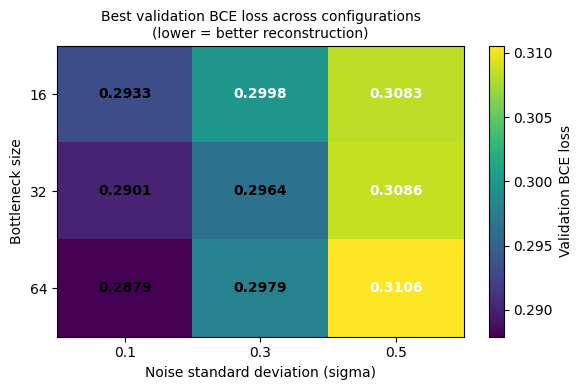

Figure 3 saved.


In [10]:
pivot = results_df.pivot(
    index='bottleneck', columns='noise', values='best_val_loss'
)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap='viridis', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(i) for i in pivot.index])
ax.set_xlabel('Noise standard deviation (sigma)', fontsize=10)
ax.set_ylabel('Bottleneck size', fontsize=10)
ax.set_title('Best validation BCE loss across configurations\n(lower = better reconstruction)',
             fontsize=10)

mean_val = pivot.values.mean()
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        text_color = 'white' if val > mean_val else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                fontsize=10, color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Validation BCE loss')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_loss_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')


## Cell 10 - Learning curves

**What this cell does:** Plots validation loss over epochs for three DAE settings (all sigma=0.3, varying bottleneck) and the plain AE baseline.

**Accessibility:** Each series uses a distinct colour from the Wong palette AND a distinct line style (solid, dashed, dot-dash, dotted) for colourblind and greyscale use.

Alt-text: Four validation BCE loss curves over training epochs. The plain AE (dotted) achieves the lowest final loss; larger DAE bottlenecks converge faster.


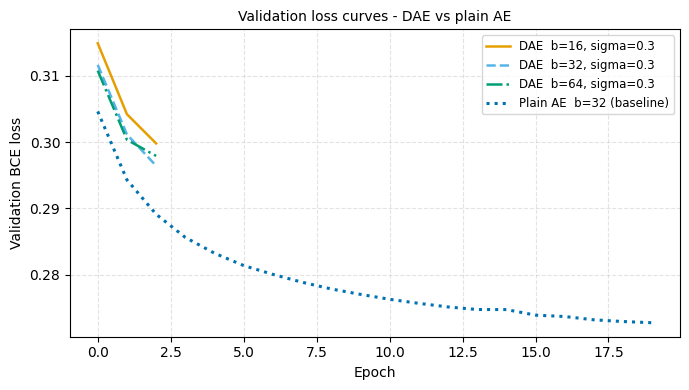

Figure 4 saved.


In [11]:
selected_keys   = [(16, 0.3), (32, 0.3), (64, 0.3)]
selected_labels = [f'DAE  b={k[0]}, sigma={k[1]}' for k in selected_keys]
line_styles     = ['-', '--', '-.']

fig, ax = plt.subplots(figsize=(7, 4))

for key, label, ls, colour in zip(
        selected_keys, selected_labels, line_styles, CB_PALETTE):
    h = histories[key]
    ax.plot(h['val_loss'], label=label, linestyle=ls,
            color=colour, linewidth=1.8)

ax.plot(
    history_baseline.history['val_loss'],
    linestyle=':', color=CB_PALETTE[4], linewidth=2.2,
    label='Plain AE  b=32 (baseline)'
)

ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Validation BCE loss', fontsize=10)
ax.set_title('Validation loss curves - DAE vs plain AE', fontsize=10)
ax.legend(fontsize=8.5)
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')


## Cell 11 - Visual reconstruction comparison

**What this cell does:**
- Finds the best DAE (lowest validation loss).
- Reconstructs 8 noisy test images with the best DAE and the plain AE.
- Displays four rows: original / noisy input / DAE reconstruction / plain AE reconstruction.

Alt-text: Four rows of eight greyscale fashion images. Row 1: clean originals. Row 2: heavily corrupted inputs. Row 3: DAE reconstructions. Row 4: plain AE reconstructions.


Best DAE: bottleneck=64, sigma=0.1  (val_loss=0.2879)


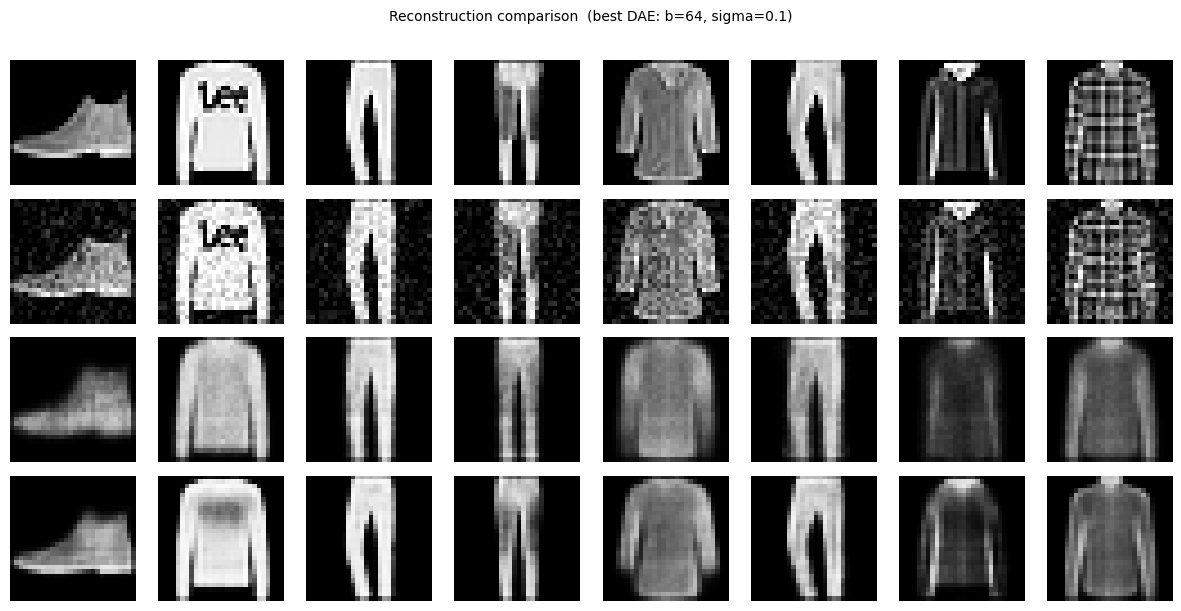

Figure 5 saved.


In [12]:
best_row   = results_df.sort_values('best_val_loss').iloc[0]
best_key   = (int(best_row['bottleneck']), float(best_row['noise']))
best_model = models[best_key]
print(f'Best DAE: bottleneck={best_key[0]}, sigma={best_key[1]}  '
      f'(val_loss={best_row["best_val_loss"]:.4f})')

N_SHOW = 8
sample_clean   = x_test[:N_SHOW]
sample_noisy   = add_gaussian_noise(sample_clean, best_key[1])
sample_recon   = best_model.predict(
    flatten_images(sample_noisy), verbose=0).reshape(-1, 28, 28)
baseline_recon = baseline_ae.predict(
    flatten_images(sample_clean), verbose=0).reshape(-1, 28, 28)

row_labels = ['Original', 'Noisy input', 'DAE recon', 'Plain AE recon']
fig, axes  = plt.subplots(4, N_SHOW, figsize=(1.5 * N_SHOW, 6))

for row_idx, images in enumerate(
        [sample_clean, sample_noisy, sample_recon, baseline_recon]):
    for col_idx in range(N_SHOW):
        axes[row_idx, col_idx].imshow(images[col_idx], cmap='gray',
                                      vmin=0, vmax=1)
        axes[row_idx, col_idx].axis('off')
    axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=9,
                                rotation=0, labelpad=70, va='center')

fig.suptitle(f'Reconstruction comparison  '
             f'(best DAE: b={best_key[0]}, sigma={best_key[1]})',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_reconstruction_comparison.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')


## Cell 12 - PCA of the latent space

**What this cell does:**
- Encodes all 10,000 test images with the best encoder.
- Projects latent vectors to 2D using PCA.
- Colours and shapes each point by class label (both colour AND marker for accessibility).
- Labels the legend with full class names and reports variance explained by each PC.

Alt-text: A 2D scatter plot of 10,000 test images projected from the latent space. Ten labelled clusters each with a distinct colour and marker shape. Visually distinct categories such as Trouser, Bag, and Sandal form tight separated clusters; similar garments like Pullover, Coat, and Shirt overlap.


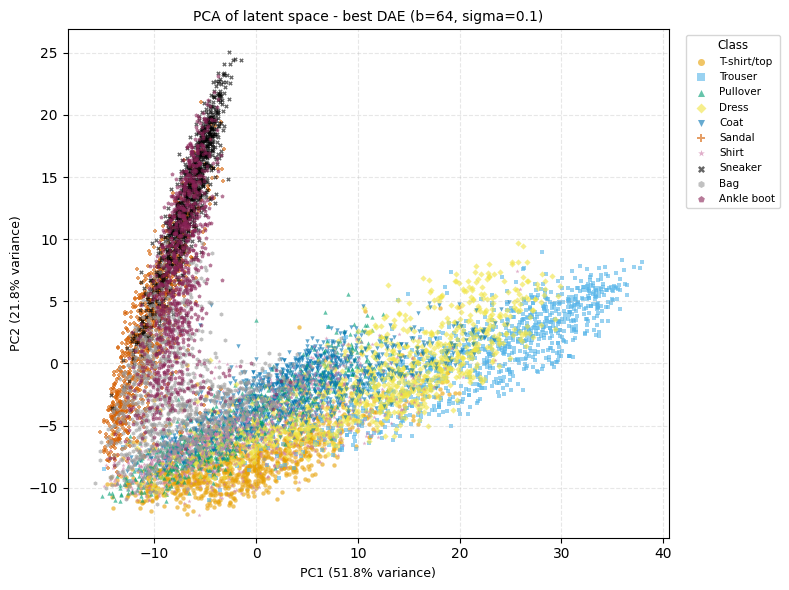

Variance explained by first 2 PCs: 73.6%
Figure 6 saved.


In [13]:
latent    = encoders[best_key].predict(x_test_flat, verbose=0)
pca       = PCA(n_components=2, random_state=SEED)
latent_2d = pca.fit_transform(latent)

MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

fig, ax = plt.subplots(figsize=(8, 6))
for class_idx, (name, colour, marker) in enumerate(
        zip(CLASS_NAMES, CB_PALETTE, MARKERS)):
    mask = y_test == class_idx
    ax.scatter(
        latent_2d[mask, 0], latent_2d[mask, 1],
        c=colour, marker=marker, s=10, alpha=0.6,
        label=name, linewidths=0
    )

ax.set_title(
    f'PCA of latent space - best DAE (b={best_key[0]}, sigma={best_key[1]})',
    fontsize=10
)
ax.set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=9
)
ax.set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=9
)
ax.legend(title='Class', fontsize=7.5, title_fontsize=8.5,
          bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=1.6)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_latent_space_pca.png', dpi=200, bbox_inches='tight')
plt.show()

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f'Variance explained by first 2 PCs: {var_explained:.1f}%')
print('Figure 6 saved.')


## Cell 13 - Downstream classification on latent features

**What this cell does:**
- Encodes train, val, and test images with the best encoder.
- Trains a logistic regression classifier on the latent features.
- Compares accuracy against a raw-pixel baseline (784 dimensions).

**Why this matters:** If the DAE latent features (16-64 dimensions) achieve comparable accuracy to raw pixels (784 dimensions), the denoising objective has produced genuinely discriminative rather than merely compressive representations.


In [14]:
# Latent-feature classifier
X_lat_train = encoders[best_key].predict(x_train_flat, verbose=0)
X_lat_val   = encoders[best_key].predict(x_val_flat,   verbose=0)
X_lat_test  = encoders[best_key].predict(x_test_flat,  verbose=0)

clf_latent = LogisticRegression(max_iter=2000, random_state=SEED)
clf_latent.fit(X_lat_train, y_train)

val_acc_latent  = accuracy_score(y_val,  clf_latent.predict(X_lat_val))
test_acc_latent = accuracy_score(y_test, clf_latent.predict(X_lat_test))

# Raw-pixel baseline
clf_pixel = LogisticRegression(max_iter=2000, random_state=SEED)
clf_pixel.fit(x_train_flat, y_train)

val_acc_pixel  = accuracy_score(y_val,  clf_pixel.predict(x_val_flat))
test_acc_pixel = accuracy_score(y_test, clf_pixel.predict(x_test_flat))

print('Classification accuracy summary')
print('=' * 55)
print(f'  Latent features ({best_key[0]}D)  val: {val_acc_latent:.4f} | test: {test_acc_latent:.4f}')
print(f'  Raw pixels      (784D)  val: {val_acc_pixel:.4f} | test: {test_acc_pixel:.4f}')
print('=' * 55)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification accuracy summary
  Latent features (64D)  val: 0.8252 | test: 0.8129
  Raw pixels      (784D)  val: 0.8613 | test: 0.8420


## Cell 14 - Save results
Saves the full experiment results to `dae_results.csv`.


In [15]:
results_df.to_csv('dae_results.csv', index=False)
print('Results saved to dae_results.csv')
print('All figures saved to:', FIG_DIR)
print()
print('=== Notebook complete ===')
print('GitHub: https://github.com/Princebenj/denoising-autoencoder-tutorial.git')


Results saved to dae_results.csv
All figures saved to: figures

=== Notebook complete ===
GitHub: https://github.com/Princebenj/denoising-autoencoder-tutorial.git
